# Business Application Summary

Business-facing summary of LightGBM model performance for falls and return-to-hospital (RTH), with ROI framing and key insights.

**Assumptions**
- Average cost per fall: $3,500
- Average cost per RTH: $20,000
- Intervention reduces falls by 20% and RTH by 10% in the flagged cohort
- Program cost per resident: set in ROI calculator (default $50 per month)

## Scope and inputs
This notebook reuses saved outputs to present a business-facing readout; it does not retrain models.

Saved/stored files used:
- reports/model_metrics.csv
- reports/lightgbm_cumulative_recall_points.csv
- reports/lightgbm_cumulative_recall_points_rth.csv
- reports/rule_cumulative_recall_points.csv
- reports/decision_tree_cumulative_recall_points.csv
- reports/feature_importance_lightgbm_fall.csv
- reports/feature_importance_lightgbm_rth.csv
- outputs/datavision_weekly_2023-08_2025-01.parquet

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for path in candidates:
        dataset_path = path / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
        if dataset_path.exists():
            return path
        if (path / "src").exists() and (path / "outputs").exists():
            return path
    raise FileNotFoundError("Could not locate repo root with outputs/datavision_weekly_2023-08_2025-01.parquet")


def find_snapshot_col(df: pd.DataFrame) -> str:
    candidates = [
        "snapshot_date"
        "snapshot_dt"
        "snapshot"
        "reference_date"
        "as_of_date"
        "week_start"
    ]
    for col in candidates:
        if col in df.columns:
            return col
    date_cols = [c for c in df.columns if any(k in c.lower() for k in ["snapshot", "reference", "as_of", "week", "date", "dt", "time"])]
    for col in date_cols:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            return col
    for col in date_cols:
        parsed = pd.to_datetime(df[col], errors="coerce")
        if parsed.notna().mean() >= 0.9:
            return col
    raise ValueError("No snapshot date column found.")


def ensure_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "fall_next_30d" not in df.columns and "label_fall_30d" in df.columns:
        df = df.rename(columns={"label_fall_30d": "fall_next_30d"})
    if "rth_next_30d" not in df.columns and "label_rth_30d" in df.columns:
        df = df.rename(columns={"label_rth_30d": "rth_next_30d"})
    missing = [c for c in ["fall_next_30d", "rth_next_30d"] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing label columns: {missing}")
    return df


def temporal_split(df: pd.DataFrame, date_col: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])
    train_start = pd.Timestamp("2023-08-28")
    train_end = pd.Timestamp("2024-07-08")
    val_start = pd.Timestamp("2024-07-15")
    val_end = pd.Timestamp("2024-09-16")
    test_start = pd.Timestamp("2024-09-23")
    test_end = pd.Timestamp("2024-11-25")
    train = df[(df[date_col] >= train_start) & (df[date_col] <= train_end)]
    val = df[(df[date_col] >= val_start) & (df[date_col] <= val_end)]
    test = df[(df[date_col] >= test_start) & (df[date_col] <= test_end)]
    return train, val, test

## Data window and splits
The temporal split is fixed to match the modeling notebooks:
- Train: 2023-08-28 to 2024-07-08
- Validation: 2024-07-15 to 2024-09-16
- Test: 2024-09-23 to 2024-11-25

The ROI calculator uses resident-level outcomes from the test window only.

In [3]:
root = find_repo_root(Path.cwd())
reports_dir = root / "reports"

metrics_path = reports_dir / "model_metrics.csv"
lgb_fall_curve_path = reports_dir / "lightgbm_cumulative_recall_points.csv"
lgb_rth_curve_path = reports_dir / "lightgbm_cumulative_recall_points_rth.csv"
rule_curve_path = reports_dir / "rule_cumulative_recall_points.csv"
tree_curve_path = reports_dir / "decision_tree_cumulative_recall_points.csv"

fi_fall_path = reports_dir / "feature_importance_lightgbm_fall.csv"
fi_rth_path = reports_dir / "feature_importance_lightgbm_rth.csv"

dataset_path = root / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
metrics_path, dataset_path

(PosixPath('/Users/marcelo.florencio/workspace/personal/tricura-incident-risk/reports/model_metrics.csv'),
 PosixPath('/Users/marcelo.florencio/workspace/personal/tricura-incident-risk/outputs/datavision_weekly_2023-08_2025-01.parquet'))

## Model Performance Summary (LightGBM)

In [4]:
metrics_df = pd.read_csv(metrics_path)
metrics_df["run_id"] = metrics_df["run_id"].astype(str)
metrics_df["run_ts"] = pd.to_datetime(metrics_df["run_id"], format="%Y%m%dT%H%M%SZ", errors="coerce")

cols = ["model", "target", "split", "recall_at_10pct", "precision_at_10pct", "roc_auc", "pr_auc"]
lgb_metrics = metrics_df[metrics_df["model"] == "lightgbm"].sort_values("run_ts")
summary = lgb_metrics.groupby(["target", "split"], as_index=False).tail(1)[cols]
summary.sort_values(["target", "split"], inplace=True)
summary

,model,target,split,recall_at_10pct,precision_at_10pct,roc_auc,pr_auc
13,lightgbm,fall_next_30d,test,0.411613,0.329545,0.825442,0.326416
12,lightgbm,fall_next_30d,val,0.709333,0.603859,0.964589,0.648262
11,lightgbm,rth_next_30d,test,0.406832,0.135331,0.793223,0.124181
10,lightgbm,rth_next_30d,val,0.801527,0.238365,0.946476,0.371018


### Latest LightGBM metrics (from reports/model_metrics.csv)
Fall model:
- Test: recall@10% = 0.412, precision@10% = 0.330

RTH model:
- Test: recall@10% = 0.407, precision@10% = 0.135

## Cumulative Recall Curves (Business View)

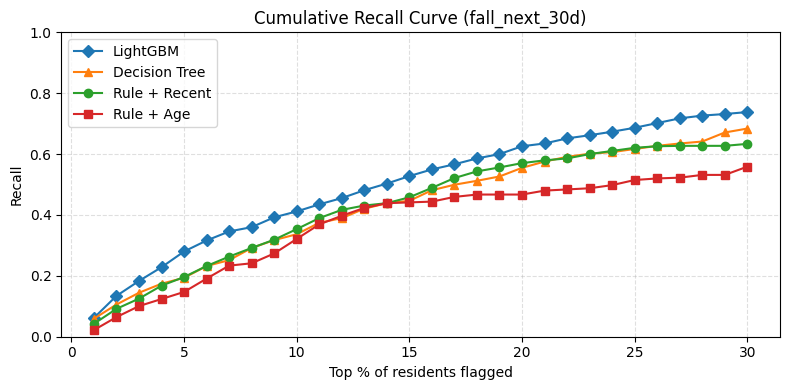

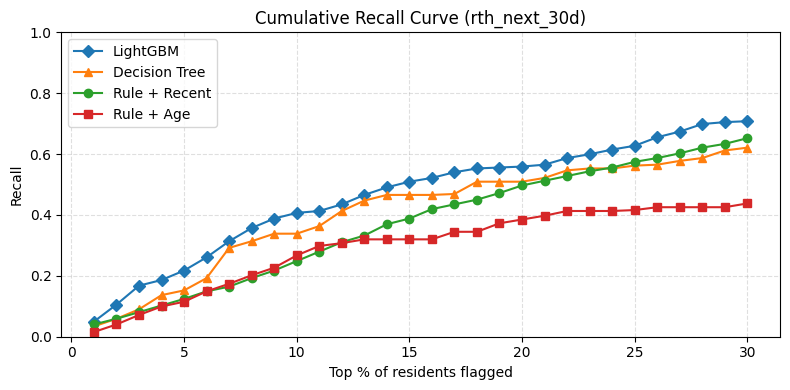

In [5]:
def plot_cumulative_recall(target: str, lgb_path: Path) -> None:
    rule_points = pd.read_csv(rule_curve_path)
    tree_points = pd.read_csv(tree_curve_path)
    lgb_points = pd.read_csv(lgb_path)

    lgb_points = lgb_points[lgb_points["target"] == target]
    rule_recent = rule_points[(rule_points["target"] == target) & (rule_points["tiebreaker"] == ("recent_fall" if target == "fall_next_30d" else "recent_admission"))]
    rule_age = rule_points[(rule_points["target"] == target) & (rule_points["tiebreaker"] == "age")]
    tree = tree_points[tree_points["target"] == target]

    plt.figure(figsize=(8, 4))
    plt.plot(lgb_points["percent_flagged"], lgb_points["recall"], marker="D", linewidth=1.5, label="LightGBM")
    plt.plot(tree["percent_flagged"], tree["recall"], marker="^", linewidth=1.5, label="Decision Tree")
    plt.plot(rule_recent["percent_flagged"], rule_recent["recall"], marker="o", linewidth=1.5, label="Rule + Recent")
    plt.plot(rule_age["percent_flagged"], rule_age["recall"], marker="s", linewidth=1.5, label="Rule + Age")
    plt.xlabel("Top % of residents flagged")
    plt.ylabel("Recall")
    plt.title(f"Cumulative Recall Curve ({target})")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_cumulative_recall("fall_next_30d", lgb_fall_curve_path)
plot_cumulative_recall("rth_next_30d", lgb_rth_curve_path)

### Curve takeaways
- LightGBM leads the baselines across the 1% to 30% flagged range for both fall and RTH targets.
- The gap is most visible at operational flag rates (around 5% to 15%).
- Rule + age is the weakest baseline, while decision trees are generally closer but still below LightGBM.

These curves are sourced from the cumulative recall exports in reports/.

## Feature Importance Highlights

In [6]:
fi_fall = pd.read_csv(fi_fall_path).sort_values("importance", ascending=False).head(15)
fi_rth = pd.read_csv(fi_rth_path).sort_values("importance", ascending=False).head(15)

print("Top Fall Features")
print(fi_fall[["feature", "importance"]])

print("Top RTH Features")
print(fi_rth[["feature", "importance"]])

Top Fall Features
                             feature     importance
0                fall_frequency_180d  477960.335999
1   physician_orders_days_since_last  402898.063015
2          incidents_days_since_last  219402.267328
3            vitals_respiration_last  188907.129990
4             care_plans_count_total   99004.224457
5                incidents_count_90d   92726.128271
6               days_since_admission   91613.440100
7                                age   91419.001926
8         care_plans_days_since_last   78069.902412
9              vitals_weight_max_90d   74450.228802
10                  vitals_count_90d   62856.934108
11            vitals_weight_mean_90d   61340.314493
12       physician_orders_count_180d   58661.922050
13           vitals_o2_sats_mean_90d   55415.850248
14            facility_fall_rate_90d   53589.628277
Top RTH Features
                         feature  importance
0          vitals_weight_min_90d         185
1           diagnoses_count_180d         17

### Feature themes (top importances)
Fall signal concentrates on recent falls/incidents, orders recency, care plan activity, and vital sign history.
RTH signal emphasizes vitals (weight, BP, O2 sats), diagnosis burden, hospital transfer counts, and age.

These are global importances from the LightGBM training artifacts and should be paired with clinical review.

## ROI Calculator (Default Assumptions)

In [7]:
df = pd.read_parquet(dataset_path)
df = ensure_labels(df)
date_col = find_snapshot_col(df)
_, _, test_df = temporal_split(df, date_col)

flag_rate = 0.10
reduction_rate_fall = 0.20
reduction_rate_rth = 0.10
cost_fall = 3500.0
cost_rth = 20000.0
program_cost_per_resident = 50.0

id_candidates = ["resident_id", "person_id", "patient_id"]
resident_id_col = next((col for col in id_candidates if col in test_df.columns), None)
if resident_id_col is None:
    raise ValueError("No resident identifier column found in test data.")

resident_labels = test_df.groupby(resident_id_col, as_index=True).agg(
    fall_any=("fall_next_30d", "max"),
    rth_any=("rth_next_30d", "max"),
)

resident_count = len(resident_labels)
flagged = max(1, int(resident_count * flag_rate))

base_fall = float(resident_labels["fall_any"].mean())
base_rth = float(resident_labels["rth_any"].mean())

metrics_local = metrics_df.copy()
if "run_ts" not in metrics_local.columns:
    metrics_local["run_ts"] = pd.to_datetime(metrics_local["run_id"].astype(str), format="%Y%m%dT%H%M%SZ", errors="coerce")
lgb_metrics = metrics_local[metrics_local["model"] == "lightgbm"].sort_values("run_ts")

def latest_metric_value(target: str, split: str, field: str, fallback: float) -> float:
    rows = lgb_metrics[(lgb_metrics["target"] == target) & (lgb_metrics["split"] == split)]
    if rows.empty:
        return fallback
    value = rows.iloc[-1][field]
    return float(value) if pd.notna(value) else fallback

def pick_score_col(candidates: list[str], columns: list[str]) -> str | None:
    for col in candidates:
        if col in columns:
            return col
    return None

def precision_at_k(scores: pd.Series, labels: pd.Series, n_top: int, fallback: float) -> float:
    scores = scores.reindex(labels.index)
    valid = scores.notna()
    if valid.sum() == 0:
        return fallback
    scores = scores[valid]
    labels = labels[valid]
    n_top = max(1, min(n_top, len(scores)))
    top_ids = scores.sort_values(ascending=False).head(n_top).index
    return float(labels.loc[top_ids].mean())

fall_score_candidates = [
    "score_fall_30d",
    "score_fall",
    "fall_score",
    "fall_risk",
    "pred_fall_30d",
    "pred_fall",
    "prob_fall_30d",
    "prob_fall",
]
rth_score_candidates = [
    "score_rth_30d",
    "score_rth",
    "rth_score",
    "rth_risk",
    "pred_rth_30d",
    "pred_rth",
    "prob_rth_30d",
    "prob_rth",
]

fall_score_col = pick_score_col(fall_score_candidates, list(test_df.columns))
rth_score_col = pick_score_col(rth_score_candidates, list(test_df.columns))

if fall_score_col:
    fall_scores = test_df.groupby(resident_id_col)[fall_score_col].max()
    precision_fall = precision_at_k(fall_scores, resident_labels["fall_any"], flagged, base_fall)
else:
    precision_fall = latest_metric_value("fall_next_30d", "test", "precision_at_10pct", base_fall)

if rth_score_col:
    rth_scores = test_df.groupby(resident_id_col)[rth_score_col].max()
    precision_rth = precision_at_k(rth_scores, resident_labels["rth_any"], flagged, base_rth)
else:
    precision_rth = latest_metric_value("rth_next_30d", "test", "precision_at_10pct", base_rth)

baseline_prevented_fall = flagged * base_fall * reduction_rate_fall
baseline_prevented_rth = flagged * base_rth * reduction_rate_rth

prevented_fall = flagged * precision_fall * reduction_rate_fall
prevented_rth = flagged * precision_rth * reduction_rate_rth

lift_fall = np.nan if baseline_prevented_fall == 0 else prevented_fall / baseline_prevented_fall
lift_rth = np.nan if baseline_prevented_rth == 0 else prevented_rth / baseline_prevented_rth

savings_fall = prevented_fall * cost_fall
savings_rth = prevented_rth * cost_rth
total_savings = savings_fall + savings_rth

program_cost_total = program_cost_per_resident * flagged
net_savings = total_savings - program_cost_total
roi_ratio = np.nan if program_cost_total == 0 else net_savings / program_cost_total

roi_table = pd.DataFrame([
    {"metric": "Resident population (test window)", "value": resident_count},
    {"metric": "Flagged residents (10%)", "value": flagged},
    {"metric": "Fall base rate (resident-level)", "value": base_fall},
    {"metric": "RTH base rate (resident-level)", "value": base_rth},
    {"metric": "Precision at 10% (fall)", "value": precision_fall},
    {"metric": "Precision at 10% (RTH)", "value": precision_rth},
    {"metric": "Baseline prevented falls", "value": baseline_prevented_fall},
    {"metric": "Baseline prevented RTH", "value": baseline_prevented_rth},
    {"metric": "Model prevented falls", "value": prevented_fall},
    {"metric": "Model prevented RTH", "value": prevented_rth},
    {"metric": "Model lift (fall)", "value": lift_fall},
    {"metric": "Model lift (RTH)", "value": lift_rth},
    {"metric": "Estimated fall savings", "value": savings_fall},
    {"metric": "Estimated RTH savings", "value": savings_rth},
    {"metric": "Estimated total savings", "value": total_savings},
    {"metric": "Program cost per resident (monthly)", "value": program_cost_per_resident},
    {"metric": "Program cost total", "value": program_cost_total},
    {"metric": "Net savings", "value": net_savings},
    {"metric": "Net ROI (net savings / cost)", "value": roi_ratio},
])
roi_table

,metric,value
0,Resident population (test window),1309.000000
1,Flagged residents (10%),130.000000
2,Fall base rate (resident-level),0.161956
3,RTH base rate (resident-level),0.067227
4,Precision at 10% (fall),0.329545
5,Precision at 10% (RTH),0.135331
6,Baseline prevented falls,4.210848
7,Baseline prevented RTH,0.873950
8,Model prevented falls,8.568182
9,Model prevented RTH,1.759298


### ROI snapshot (default assumptions)
Test-window resident population is 1,309 and the 10% flagged cohort is 130 residents.

Key outputs:
- Base rates: fall = 0.162, RTH = 0.067
- Precision at 10%: fall = 0.330, RTH = 0.135
- Model lift: ~2.03x for falls, ~2.01x for RTH
- Estimated savings: $65,174.59 total ($29,988.64 fall + $35,185.95 RTH)
- Program cost: $6,500.00 per month
- Net savings: $58,674.59 with net ROI = 9.03

If score columns are present in the dataset, precision is computed from those scores; otherwise it falls back to the latest test precision from reports/model_metrics.csv.

## Business Insights
- LightGBM models outperform rule-based and decision-tree baselines on cumulative recall at comparable flag rates.
- The 10% flagged cohort provides a controllable operational workload, with recall tradeoffs shown in the curves.
- ROI is driven by base incident rates and intervention effectiveness; use the calculator to test program costs.
- Feature importance highlights the most actionable drivers for care teams and program design.